# Water Quality Analysis 

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
kaggle_csv = None
try:
    import kagglehub
    dataset_dir = Path(kagglehub.dataset_download('mssmartypants/water-quality'))
    csv_candidates = list(dataset_dir.rglob('*.csv'))
    if csv_candidates:
        kaggle_csv = csv_candidates[0]
        print('Kaggle file detected:', kaggle_csv)
except Exception as e:
    print('Kaggle auto-download not available:', e)

data_candidates = [
    Path('waterQuality1.csv'),
    Path('water_quality.csv'),
    Path('data/waterQuality1.csv'),
]

if kaggle_csv is not None:
    data_candidates.insert(0, kaggle_csv)

csv_path = next((p for p in data_candidates if p.exists()), None)
if csv_path is None:
    found_csv = list(Path('.').glob('*.csv'))
    if not found_csv:
        raise FileNotFoundError('Place the dataset CSV in this folder or enable Kaggle access.')
    csv_path = found_csv[0]

df = pd.read_csv(csv_path)
print('Loaded:', csv_path)
print('Shape:', df.shape)

Kaggle file detected: C:\Users\Admin\.cache\kagglehub\datasets\mssmartypants\water-quality\versions\3\waterQuality1.csv
Loaded: C:\Users\Admin\.cache\kagglehub\datasets\mssmartypants\water-quality\versions\3\waterQuality1.csv
Shape: (7999, 21)


In [3]:
df.head()

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
0,1.65,9.08,0.04,2.85,0.007,0.35,0.83,0.17,0.05,0.20,...,0.054,16.08,1.13,0.007,37.75,6.78,0.08,0.34,0.02,1
1,2.32,21.16,0.01,3.31,0.002,5.28,0.68,0.66,0.90,0.65,...,0.100,2.01,1.93,0.003,32.26,3.21,0.08,0.27,0.05,1
2,1.01,14.02,0.04,0.58,0.008,4.24,0.53,0.02,0.99,0.05,...,0.078,14.16,1.11,0.006,50.28,7.07,0.07,0.44,0.01,0
3,1.36,11.33,0.04,2.96,0.001,7.23,0.03,1.66,1.08,0.71,...,0.016,1.41,1.29,0.004,9.12,1.72,0.02,0.45,0.05,1
4,0.92,24.33,0.03,0.20,0.006,2.67,0.69,0.57,0.61,0.13,...,0.117,6.74,1.11,0.003,16.90,2.41,0.02,0.06,0.02,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7999 entries, 0 to 7998
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   aluminium    7999 non-null   float64
 1   ammonia      7999 non-null   str    
 2   arsenic      7999 non-null   float64
 3   barium       7999 non-null   float64
 4   cadmium      7999 non-null   float64
 5   chloramine   7999 non-null   float64
 6   chromium     7999 non-null   float64
 7   copper       7999 non-null   float64
 8   flouride     7999 non-null   float64
 9   bacteria     7999 non-null   float64
 10  viruses      7999 non-null   float64
 11  lead         7999 non-null   float64
 12  nitrates     7999 non-null   float64
 13  nitrites     7999 non-null   float64
 14  mercury      7999 non-null   float64
 15  perchlorate  7999 non-null   float64
 16  radium       7999 non-null   float64
 17  selenium     7999 non-null   float64
 18  silver       7999 non-null   float64
 19  uranium      7999

In [5]:
df = df[df['is_safe'] != '#NUM!']
df['ammonia'] = pd.to_numeric(df['ammonia'], errors='coerce')
df['is_safe'] = pd.to_numeric(df['is_safe'], errors='coerce')

df.describe().T

,count,mean,std,min,25%,50%,75%,max
aluminium,7996.0,0.666396,1.265323,0.00,0.0400,0.070,0.2800,5.05
ammonia,7996.0,14.278212,8.878930,-0.08,6.5775,14.130,22.1325,29.84
arsenic,7996.0,0.161477,0.252632,0.00,0.0300,0.050,0.1000,1.05
barium,7996.0,1.567928,1.216227,0.00,0.5600,1.190,2.4825,4.94
cadmium,7996.0,0.042803,0.036049,0.00,0.0080,0.040,0.0700,0.13
chloramine,7996.0,2.177589,2.567210,0.00,0.1000,0.530,4.2400,8.68
chromium,7996.0,0.247300,0.270663,0.00,0.0500,0.090,0.4400,0.90
copper,7996.0,0.805940,0.653595,0.00,0.0900,0.750,1.3900,2.00
flouride,7996.0,0.771646,0.435423,0.00,0.4075,0.770,1.1600,1.50
bacteria,7996.0,0.319714,0.329497,0.00,0.0000,0.220,0.6100,1.00


In [6]:
print('Columns:', df.columns.tolist())
print('\nData types:')
print(df.dtypes)

Columns: ['aluminium', 'ammonia', 'arsenic', 'barium', 'cadmium', 'chloramine', 'chromium', 'copper', 'flouride', 'bacteria', 'viruses', 'lead', 'nitrates', 'nitrites', 'mercury', 'perchlorate', 'radium', 'selenium', 'silver', 'uranium', 'is_safe']

Data types:
aluminium      float64
ammonia        float64
arsenic        float64
barium         float64
cadmium        float64
chloramine     float64
chromium       float64
copper         float64
flouride       float64
bacteria       float64
viruses        float64
lead           float64
nitrates       float64
nitrites       float64
mercury        float64
perchlorate    float64
radium         float64
selenium       float64
silver         float64
uranium        float64
is_safe          int64
dtype: object


In [7]:
target_col = 'is_safe'
print('Target unique values:', sorted(df[target_col].dropna().unique().tolist()))
print(df[target_col].value_counts(dropna=False))

Target unique values: [0, 1]
is_safe
0    7084
1     912
Name: count, dtype: int64


In [8]:
missing_summary = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2)
}).sort_values('missing_pct', ascending=False)
missing_summary

,missing_count,missing_pct
aluminium,0,0.0
ammonia,0,0.0
arsenic,0,0.0
barium,0,0.0
cadmium,0,0.0
chloramine,0,0.0
chromium,0,0.0
copper,0,0.0
flouride,0,0.0
bacteria,0,0.0


In [9]:
plt.figure(figsize=(10, 5))
missing_plot = missing_summary[missing_summary['missing_pct'] > 0]
if len(missing_plot) > 0:
    sns.barplot(data=missing_plot.reset_index(), x='index', y='missing_pct', color='#2a9d8f')
    plt.xticks(rotation=45)
    plt.xlabel('Feature')
    plt.ylabel('Missing (%)')
    plt.title('Missing Value Percentage by Feature')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found.')

No missing values found.


<Figure size 1000x500 with 0 Axes>

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print(df.isna().sum())

aluminium      0
ammonia        0
arsenic        0
barium         0
cadmium        0
chloramine     0
chromium       0
copper         0
flouride       0
bacteria       0
viruses        0
lead           0
nitrates       0
nitrites       0
mercury        0
perchlorate    0
radium         0
selenium       0
silver         0
uranium        0
is_safe        0
dtype: int64


In [11]:
duplicate_count = df.duplicated().sum()
print('Duplicate rows:', duplicate_count)

Duplicate rows: 0


In [12]:
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
print('Shape after duplicate handling:', df.shape)

Shape after duplicate handling: (7996, 21)


In [13]:
outlier_rows = []
for col in [c for c in numeric_cols if c != target_col]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append({'feature': col, 'outlier_count': int(outlier_count), 'outlier_pct': round((outlier_count / len(df)) * 100, 2)})

outlier_summary = pd.DataFrame(outlier_rows).sort_values('outlier_pct', ascending=False)
outlier_summary

,feature,outlier_count,outlier_pct
0,aluminium,1731,21.65
2,arsenic,1634,20.44
13,nitrites,2,0.03
1,ammonia,0,0.00
3,barium,0,0.00
4,cadmium,0,0.00
6,chromium,0,0.00
5,chloramine,0,0.00
8,flouride,0,0.00
9,bacteria,0,0.00


In [14]:
df = df.dropna(subset=[target_col])
X = df.drop(columns=[target_col]).copy()
y = df[target_col].astype(int).copy()

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Class labels:', sorted(y.unique().tolist()))

X shape: (7996, 20)
y shape: (7996,)
Class labels: [0, 1]


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


print('Train shapes:', X_train.shape, y_train.shape)
print('Test shapes:', X_test.shape, y_test.shape)

Train shapes: (6396, 20) (6396,)
Test shapes: (1600, 20) (1600,)


In [16]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled.head()

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,viruses,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium
5068,-0.484890,-0.472986,-0.477678,-0.876791,-1.182717,-0.851903,-0.728519,1.132847,0.731356,-0.964417,1.043011,0.638781,0.870533,-1.211065,-1.413404,-0.938492,-0.612495,1.396666,-0.611341,-0.544228
5776,-0.500476,1.093874,-0.437679,-0.589425,-0.353022,-0.805223,-0.691613,-0.934454,-1.120885,0.431343,-0.849207,0.226194,0.384267,-1.088525,-0.064986,-0.811201,-1.003848,1.744785,-0.960990,0.937155
5493,-0.516063,1.046564,-0.477678,0.034570,-1.182717,-0.824673,-0.691613,0.704074,-1.280955,-0.964417,0.910502,-0.134820,-0.729263,-1.088525,1.620536,-0.655748,-1.128565,1.048547,-0.681271,1.677847
4590,-0.516063,-1.297531,-0.597674,-0.876791,0.753237,-0.824673,-0.839238,-1.194781,-0.068995,-0.964417,1.652549,0.415296,1.013340,-1.456143,-1.750508,-0.725026,-1.033952,1.048547,-0.681271,0.937155
7241,-0.492683,-1.177003,-0.637673,-1.180577,-0.906152,-0.606834,-0.654706,1.806635,1.531707,-0.509278,-0.857158,0.002709,-0.958839,2.325068,1.620536,-0.718267,-0.840426,-1.040165,-0.891060,-0.173882


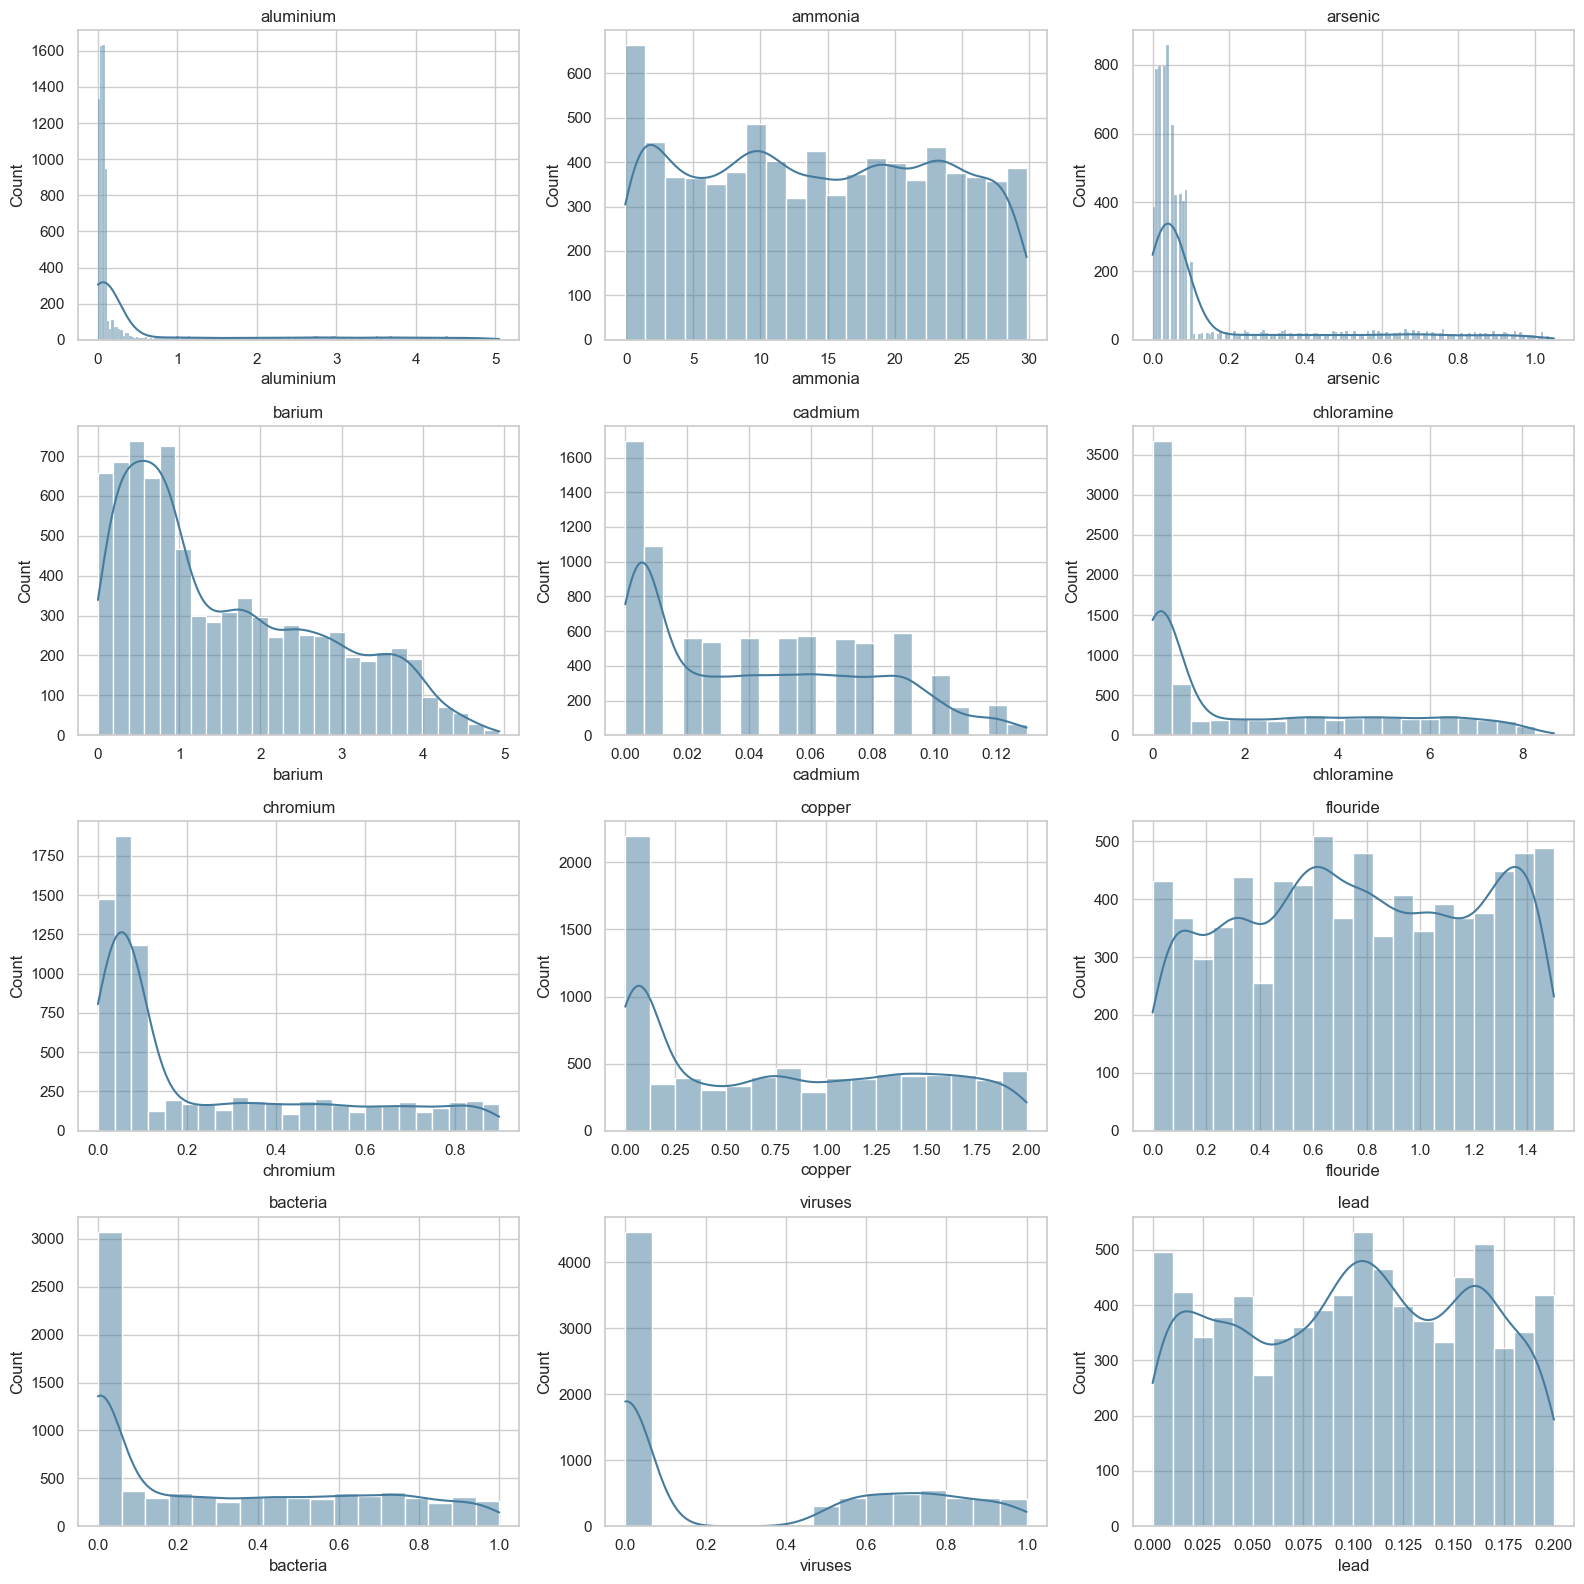

In [17]:
feature_cols = X.columns.tolist()
plot_cols = feature_cols[:12]
if len(plot_cols) > 0:
    n_cols = 3
    n_rows = int(np.ceil(len(plot_cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(plot_cols):
        sns.histplot(df[col], kde=True, ax=axes[i], color='#457b9d')
        axes[i].set_title(col)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

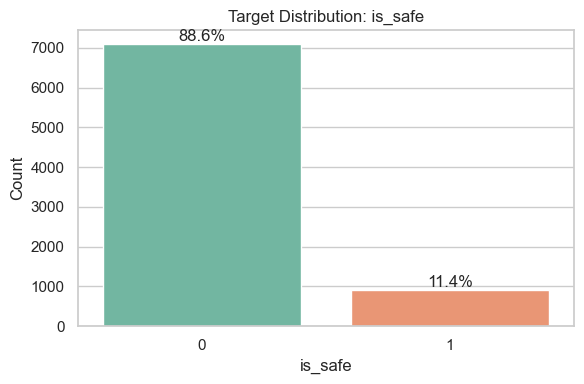

In [18]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=target_col, data=df, palette='Set2')
plt.title(f'Target Distribution: {target_col}')
plt.xlabel(target_col)
plt.ylabel('Count')

total = len(df)
for p in ax.patches:
    pct = 100 * p.get_height() / total
    ax.annotate(f'{pct:.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')

plt.tight_layout()
plt.show()

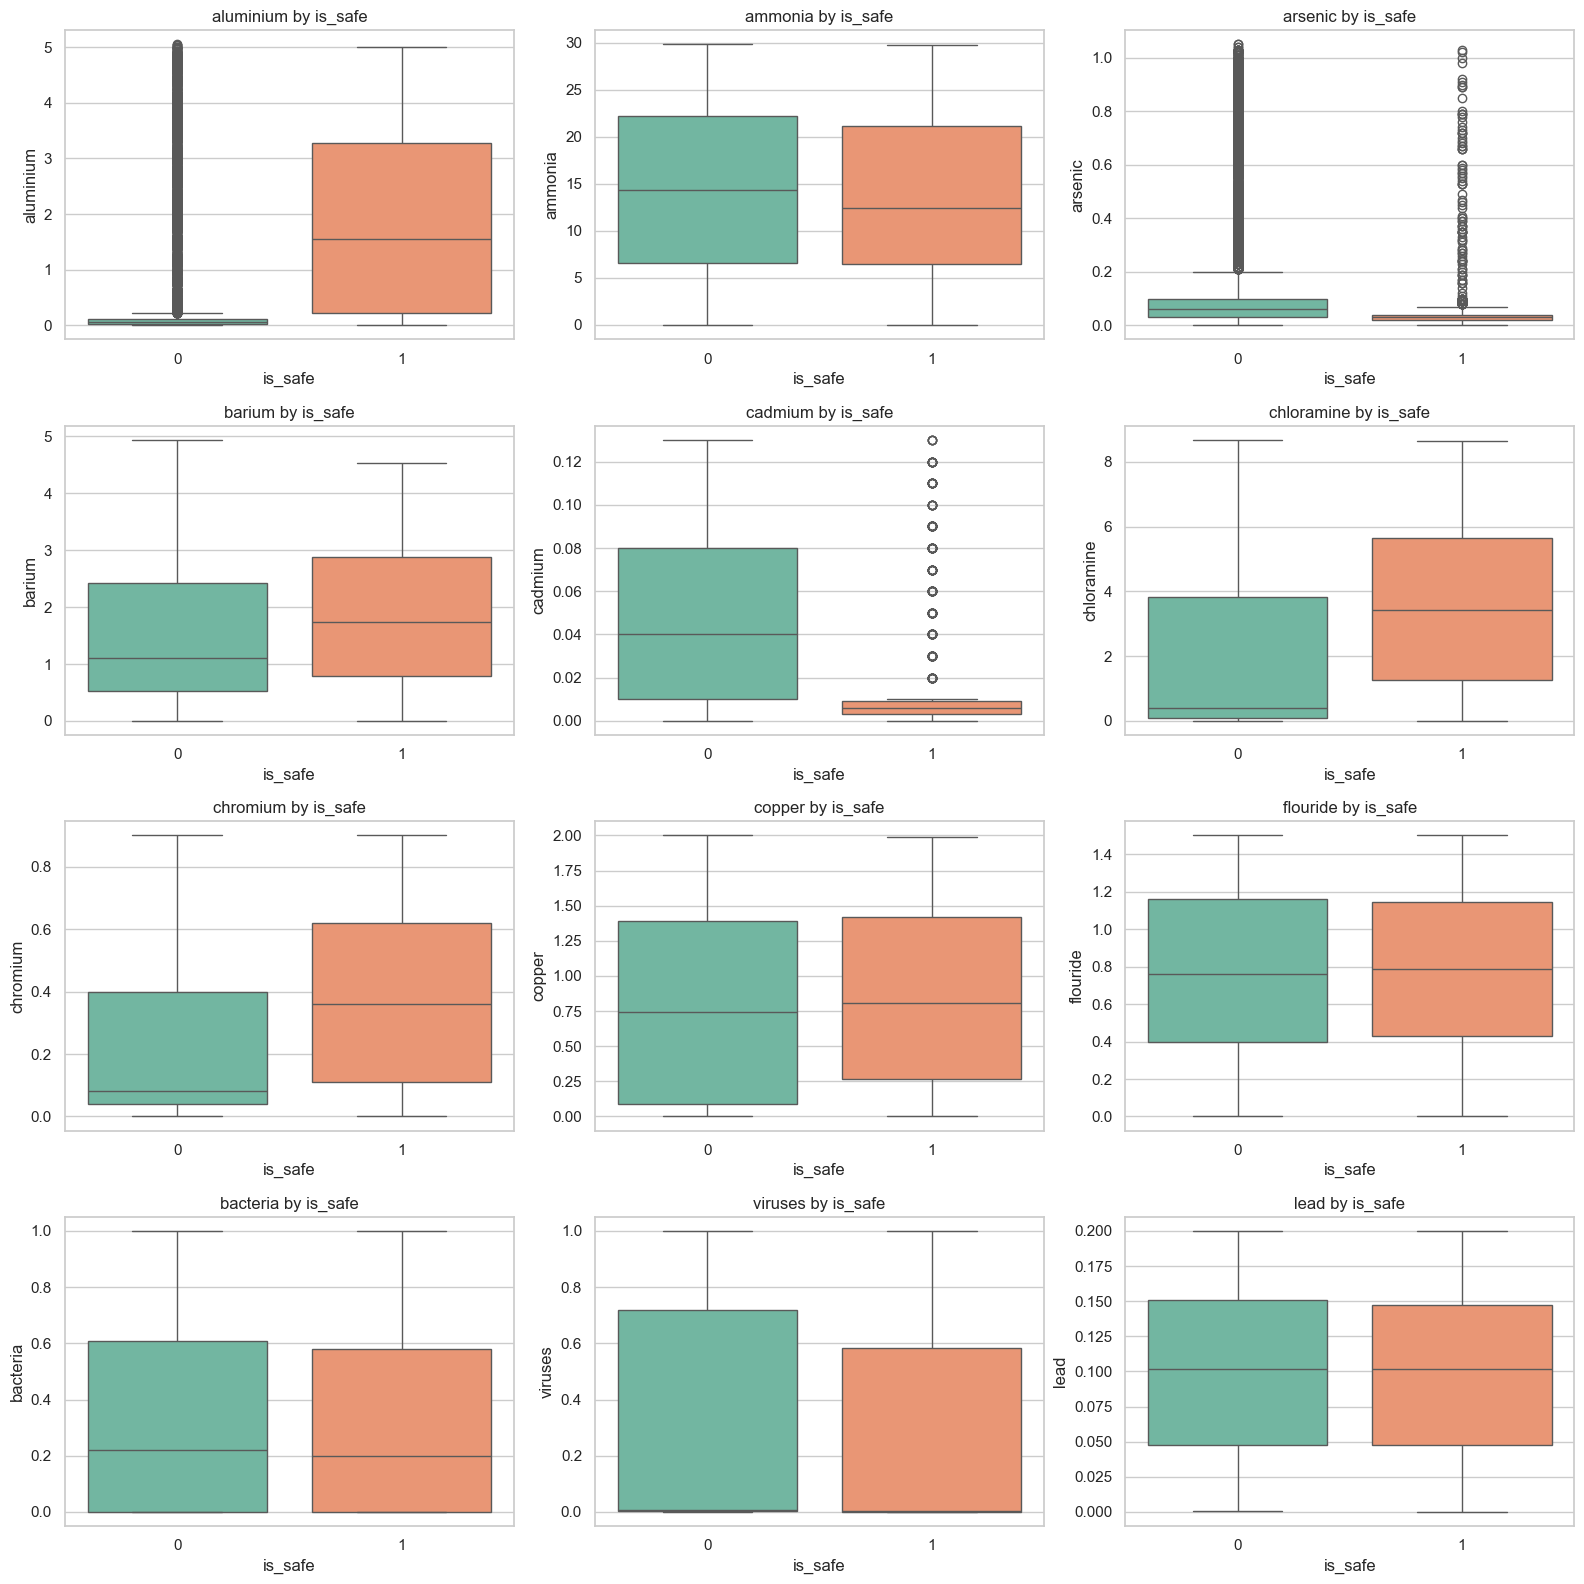

In [19]:
if len(plot_cols) > 0:
    n_cols = 3
    n_rows = int(np.ceil(len(plot_cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(plot_cols):
        sns.boxplot(x=target_col, y=col, data=df, ax=axes[i], palette='Set2')
        axes[i].set_title(f'{col} by {target_col}')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

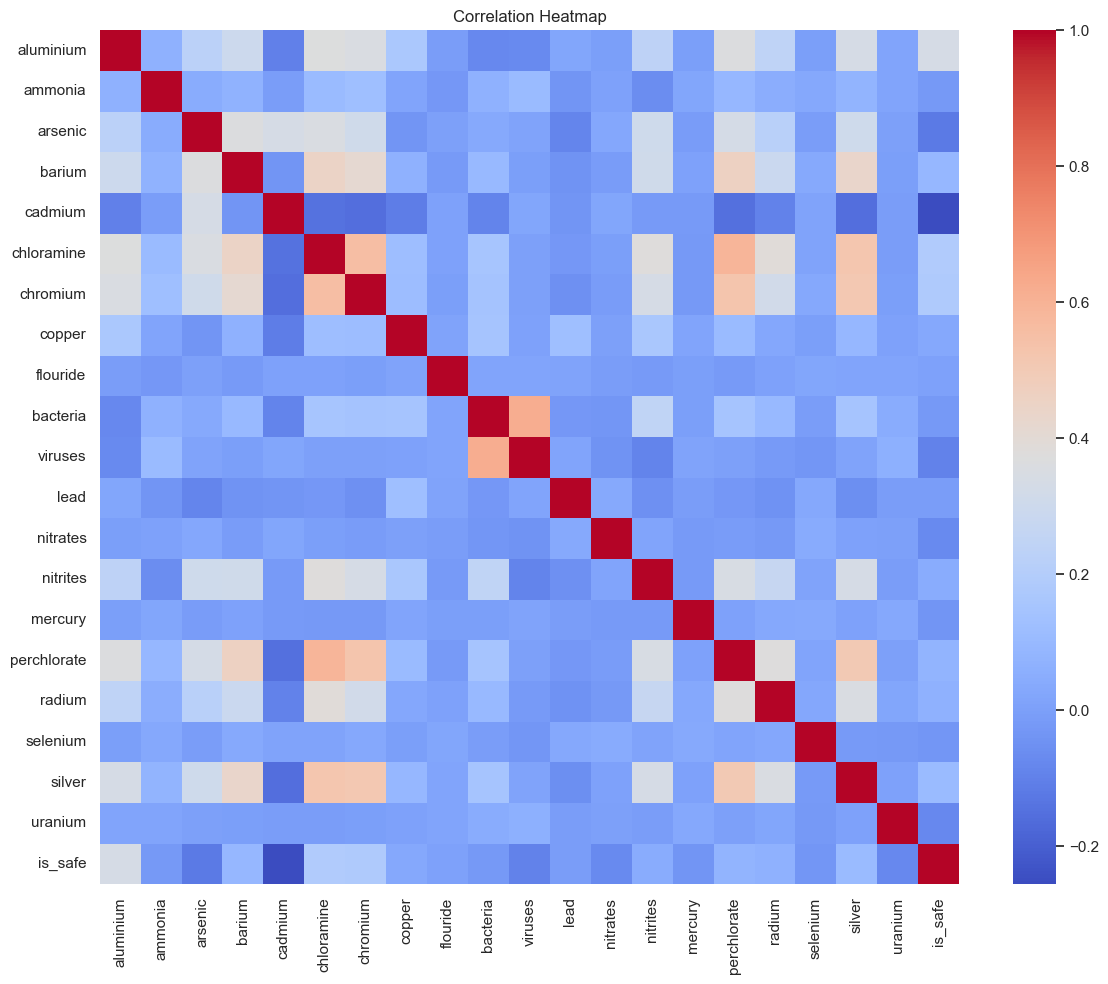

In [20]:
plt.figure(figsize=(12, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap='coolwarm', square=False)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

Top features vs is_safe : ['aluminium', 'cadmium', 'chloramine']


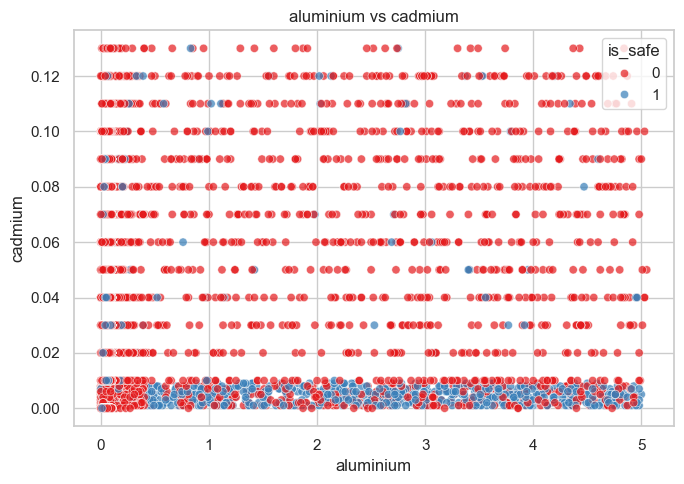

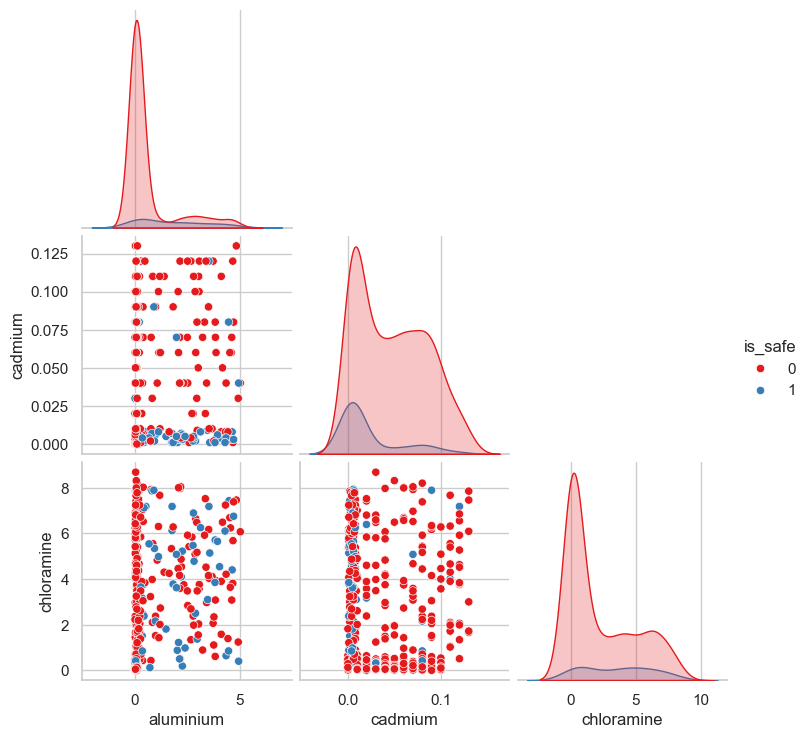

In [21]:
top_features = corr[target_col].drop(target_col).abs().sort_values(ascending=False).head(3).index.tolist()
print('Top features vs', target_col, ':', top_features)

if len(top_features) >= 2:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=df, x=top_features[0], y=top_features[1], hue=target_col, alpha=0.7, palette='Set1')
    plt.title(f'{top_features[0]} vs {top_features[1]}')
    plt.tight_layout()
    plt.show()

if len(top_features) >= 3:
    sample_df = df[[top_features[0], top_features[1], top_features[2], target_col]].sample(
        n=min(500, len(df)), random_state=42
    )
    sns.pairplot(sample_df, hue=target_col, diag_kind='kde', corner=True, palette='Set1')
    plt.show()

In [22]:
output_dir = Path('processed_outputs')
output_dir.mkdir(exist_ok=True)

df.to_csv(output_dir / 'water_quality_cleaned.csv', index=False)

X_train_scaled.to_csv(output_dir / 'X_train_scaled.csv', index=False)
X_test_scaled.to_csv(output_dir / 'X_test_scaled.csv', index=False)
y_train.to_csv(output_dir / 'y_train.csv', index=False)
y_test.to_csv(output_dir / 'y_test.csv', index=False)

print('Saved files to:', output_dir.resolve())

Saved files to: C:\Users\Admin\OneDrive\Desktop\Water Potability\Water Quality Dataset\processed_outputs


In [23]:
clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
print('Model trained successfully')

Model trained successfully


In [26]:
print("Fetching benchmark metrics...")
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=42),
    'KNN (k=11)': KNeighborsClassifier(n_neighbors=11),
    'RandomForest (tuned)': RandomForestClassifier(
        n_estimators=500,
        max_depth=14,
        random_state=42,
        class_weight='balanced_subsample'
    ),
    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=500,
        max_depth=14,
        random_state=42,
        class_weight='balanced'
    ),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
}

benchmark_rows = []
best_name = None
best_acc = -1
best_model = None

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    score = accuracy_score(y_test, pred)
    benchmark_rows.append({'model': name, 'accuracy': round(score, 4)})
    if score > best_acc:
        best_acc = score
        best_name = name
        best_model = model

benchmark_df = pd.DataFrame(benchmark_rows).sort_values('accuracy', ascending=False)
print(benchmark_df)
print(f'Best model: {best_name} | Accuracy: {best_acc:.4f}')

train_acc = accuracy_score(y_train, best_model.predict(X_train_scaled))
test_acc = accuracy_score(y_test, best_model.predict(X_test_scaled))
print(f'\nTrain accuracy: {train_acc:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

Fetching benchmark metrics...
                  model  accuracy
4      GradientBoosting    0.9587
2  RandomForest (tuned)    0.9575
3            ExtraTrees    0.9363
1            KNN (k=11)    0.9144
0    LogisticRegression    0.9087
Best model: GradientBoosting | Accuracy: 0.9587

Train accuracy: 0.9712
Test accuracy: 0.9587


In [27]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Original train shape:", X_train_scaled.shape, y_train.shape)
print("Original class distribution:\n", y_train.value_counts())
print("\nSMOTE train shape:", X_train_smote.shape, y_train_smote.shape)
print("SMOTE class distribution:\n", y_train_smote.value_counts())

Original train shape: (6396, 20) (6396,)
Original class distribution:
 is_safe
0    5666
1     730
Name: count, dtype: int64

SMOTE train shape: (11332, 20) (11332,)
SMOTE class distribution:
 is_safe
0    5666
1    5666
Name: count, dtype: int64


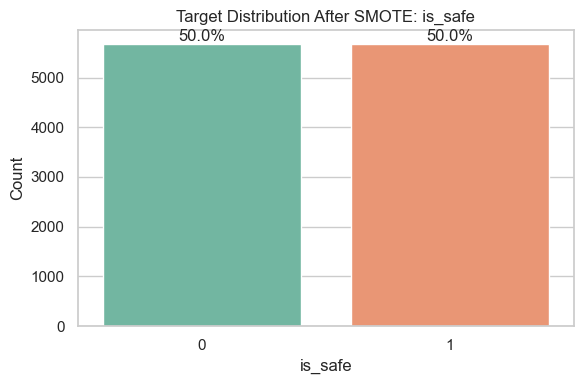

In [29]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=y_train_smote, palette='Set2')
plt.title(f'Target Distribution After SMOTE: {target_col}')
plt.xlabel(target_col)
plt.ylabel('Count')

total = len(y_train_smote)
for p in ax.patches:
    pct = 100 * p.get_height() / total
    ax.annotate(f'{pct:.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [28]:
print("Running benchmark WITH SMOTE balanced data...")
models_smote = {
    'LogisticRegression (SMOTE)': LogisticRegression(max_iter=2000, random_state=42),
    'RandomForest (SMOTE)': RandomForestClassifier(n_estimators=500, max_depth=14, random_state=42),
    'ExtraTrees (SMOTE)': ExtraTreesClassifier(n_estimators=500, max_depth=14, random_state=42),
    'GradientBoosting (SMOTE)': GradientBoostingClassifier(random_state=42)
}

metrics_smote = []

for name, model in models_smote.items():
    model.fit(X_train_smote, y_train_smote)
    pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average='weighted')
    rec = recall_score(y_test, pred, pos_label=1)  # Focus on minority class recall
    
    metrics_smote.append({
        'Model': name, 
        'Overall Accuracy': round(acc, 4),
        'Weighted F1': round(f1, 4),
        'Minority Class (1) Recall': round(rec, 4)
    })

smote_df = pd.DataFrame(metrics_smote).sort_values('Minority Class (1) Recall', ascending=False)
smote_df

Running benchmark WITH SMOTE balanced data...


,Model,Overall Accuracy,Weighted F1,Minority Class (1) Recall
3,GradientBoosting (SMOTE),0.9481,0.9497,0.8462
1,RandomForest (SMOTE),0.9563,0.9568,0.8352
2,ExtraTrees (SMOTE),0.9294,0.9310,0.7473
0,LogisticRegression (SMOTE),0.8031,0.8312,0.7088


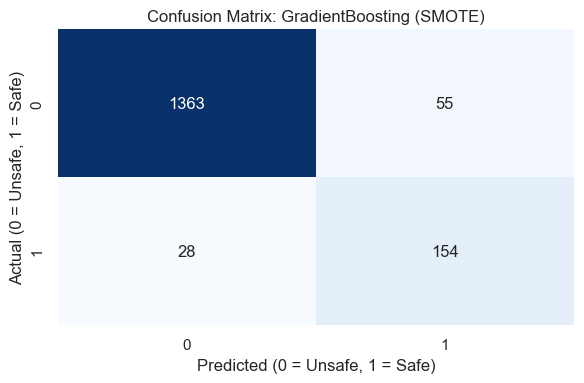

In [30]:
best_model_name = smote_df.iloc[0]['Model']
best_model_smote = models_smote[best_model_name]
y_pred_final = best_model_smote.predict(X_test_scaled)

cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix: {best_model_name}')
plt.xlabel('Predicted (0 = Unsafe, 1 = Safe)')
plt.ylabel('Actual (0 = Unsafe, 1 = Safe)')
plt.tight_layout()
plt.show()

In [49]:
def test_water_quality(sample_index=None):
    if sample_index is None:
        sample_index = X_test.sample(1).index[0]
        
    print(f"--- Testing Water Sample #{sample_index} ---")
    
    raw_data = X_test.loc[[sample_index]]
    actual_status = y_test.loc[sample_index]
    
    print("\nRaw Sensor Readings:")
    print(raw_data.T.to_string(header=False))
    
    scaled_data = scaler.transform(raw_data)
    
    prediction = best_model_smote.predict(scaled_data)[0]
    
    print("\n======================================")
    print("AI PREDICTION:")
    if prediction == 1:
        print("SAFE TO DRINK (Potable)")
    else:
        print("WARNING: UNSAFE (Contaminated)")
        
    print(f"\nACTUAL LAB TEST RESULT:")
    if actual_status == 1:
        print("SAFE TO DRINK (Potable)")
    else:
        print("WARNING: UNSAFE (Contaminated)")
    print("======================================\n")

test_water_quality()
test_water_quality()

--- Testing Water Sample #7185 ---

Raw Sensor Readings:
aluminium     0.050
ammonia      15.080
arsenic       0.080
barium        0.270
cadmium       0.060
chloramine    0.500
chromium      0.050
copper        1.040
flouride      1.190
bacteria      0.180
viruses       0.001
lead          0.079
nitrates      8.900
nitrites      1.790
mercury       0.008
perchlorate   7.670
radium        4.160
selenium      0.030
silver        0.070
uranium       0.000

AI PREDICTION:

ACTUAL LAB TEST RESULT:

--- Testing Water Sample #1259 ---

Raw Sensor Readings:
aluminium     1.800
ammonia       9.530
arsenic       0.280
barium        2.640
cadmium       0.090
chloramine    7.200
chromium      0.150
copper        1.040
flouride      0.580
bacteria      0.000
viruses       0.500
lead          0.106
nitrates     15.470
nitrites      1.970
mercury       0.005
perchlorate  38.800
radium        4.250
selenium      0.030
silver        0.240
uranium       0.010

AI PREDICTION:

ACTUAL LAB TEST RESULT:



In [50]:
def test_water_quality(sample_index=None):
    if sample_index is None:
        sample_index = X_test.sample(1).index[0]
        
    print(f"--- Testing Water Sample #{sample_index} ---")
    
    raw_data = X_test.loc[[sample_index]]
    actual_status = y_test.loc[sample_index]
    
    print("\nRaw Sensor Readings:")
    print(raw_data.T.to_string(header=False))
    
    scaled_data = scaler.transform(raw_data)
    
    prediction = best_model_smote.predict(scaled_data)[0]
    
    print("\n======================================")
    print("AI PREDICTION:")
    if prediction == 1:
        print("SAFE TO DRINK (Potable)")
    else:
        print("WARNING: UNSAFE (Contaminated)")
        
    print(f"\nACTUAL LAB TEST RESULT:")
    if actual_status == 1:
        print("SAFE TO DRINK (Potable)")
    else:
        print("WARNING: UNSAFE (Contaminated)")
    print("======================================\n")

test_water_quality()
test_water_quality()

--- Testing Water Sample #4632 ---

Raw Sensor Readings:
aluminium     0.050
ammonia       9.170
arsenic       0.080
barium        0.340
cadmium       0.080
chloramine    0.030
chromium      0.070
copper        0.070
flouride      0.960
bacteria      0.000
viruses       0.001
lead          0.131
nitrates     18.800
nitrites      0.600
mercury       0.007
perchlorate   0.450
radium        3.350
selenium      0.080
silver        0.030
uranium       0.060

AI PREDICTION:

ACTUAL LAB TEST RESULT:

--- Testing Water Sample #7806 ---

Raw Sensor Readings:
aluminium    0.040
ammonia      2.220
arsenic      0.050
barium       0.590
cadmium      0.080
chloramine   0.450
chromium     0.070
copper       0.100
flouride     0.330
bacteria     0.000
viruses      0.000
lead         0.160
nitrates     5.850
nitrites     1.390
mercury      0.003
perchlorate  3.990
radium       4.330
selenium     0.020
silver       0.060
uranium      0.070

AI PREDICTION:

ACTUAL LAB TEST RESULT:



In [51]:
def test_water_quality(sample_index=None):
    if sample_index is None:
        sample_index = X_test.sample(1).index[0]
        
    print(f"--- Testing Water Sample #{sample_index} ---")
    
    raw_data = X_test.loc[[sample_index]]
    actual_status = y_test.loc[sample_index]
    
    print("\nRaw Sensor Readings:")
    print(raw_data.T.to_string(header=False))
    
    scaled_data = scaler.transform(raw_data)
    
    prediction = best_model_smote.predict(scaled_data)[0]
    
    print("\n======================================")
    print("AI PREDICTION:")
    if prediction == 1:
        print("SAFE TO DRINK (Potable)")
    else:
        print("WARNING: UNSAFE (Contaminated)")
        
    print(f"\nACTUAL LAB TEST RESULT:")
    if actual_status == 1:
        print("SAFE TO DRINK (Potable)")
    else:
        print("WARNING: UNSAFE (Contaminated)")
    print("======================================\n")

test_water_quality()
test_water_quality()

--- Testing Water Sample #6166 ---

Raw Sensor Readings:
aluminium     0.080
ammonia      18.610
arsenic       0.030
barium        0.960
cadmium       0.020
chloramine    0.100
chromium      0.030
copper        0.360
flouride      1.390
bacteria      0.800
viruses       0.800
lead          0.116
nitrates      3.110
nitrites      1.780
mercury       0.001
perchlorate   3.010
radium        2.500
selenium      0.060
silver        0.090
uranium       0.080

AI PREDICTION:

ACTUAL LAB TEST RESULT:

--- Testing Water Sample #510 ---

Raw Sensor Readings:
aluminium    2.690
ammonia      0.970
arsenic      0.040
barium       0.360
cadmium      0.001
chloramine   0.810
chromium     0.050
copper       0.800
flouride     0.360
bacteria     0.640
viruses      0.640
lead         0.087
nitrates     6.880
nitrites     1.070
mercury      0.010
perchlorate  0.330
radium       2.580
selenium     0.030
silver       0.060
uranium      0.080

AI PREDICTION:
SAFE TO DRINK (Potable)

ACTUAL LAB TEST RESULT:
